# Computer Vision - Part 9

## Mapping from AI to Grasping

Eight progressive lab exercises guide students from raw pixel inputs through to a complete simulated grasp pipeline, culminating in hardware demo on Swift or Yahboom arm.

In [35]:
!pip install spatialmath-python


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


#### From AI to Robotics

Four clearly-defined steps from raw image to robot motion — each building on the last.

``Capture -> Hand-Eye -> Gripper -> Offset -> IK Solve``

This four-step pipeline is the central deliverable of Week 9 and the backbone of the end-of-course AI → Robot demo.

All Transforms in the Grasping Problem
- `T_BC`: Pose of camera in base frame. Result of hand-eye calibration. Fixed as long as camera mount is unchanged.

- `T_CO`: Pose of object in camera frame. Output of the 6D pose network from Week 5. Changes with every new image capture.

- `T_OT`: Offset of TCP relative to the object. Defined by the gripper design and grasp strategy. Set once during system design.

- `T_BT (= T_target)`: TCP pose in base frame — the final IK input. Computed as: `T_BO × T_OT`, where `T_BO = T_BC × T_CO`.

**Computing T_target for IK**
The chain of matrix multiplications that transforms the AI output into an actionable robot command:

$$T_{BO} = T_{BC} \times T_{CO}$$
$$T_{BT} = T_{BO} \times T_{OT}$$
$$T_{target} = T_{BT}$$

T_target is the direct input to the 6-DOF IK solver built in Week 8. The pipeline is now complete — from
camera observation to joint angles.
Note the order of multiplication: right-to-left composition. T_BC acts on the result of T_CO — always verify your
frame chain before coding

**Choosing the Grasp Offset T_OT**

What Is T_OT? T_OT encodes howthe gripper approaches the object. It depends on the tool type, gripper geometry, and approach strategy. It is a design decision — not estimated from data.

Common Grasp Strategies:
- Top-down grasp: TCP above object, offset along z-axis
- Side grasp: TCP offset along x or y
- Vacuum suction: approach normal to surface

Example: Top-Down Grasp

TCP 5 cm above the object center, aligned with object yaw:
```
T_OT = Trans(0, 0, d) * R_z(yaw_offset)
```

where `d = 0.05` meters (safe standoff distance perpendicular to table).

**Rule of Thumb**: Design grippers to be "forgiving": wide contact surfaces, vacuum suction, or chamfered guides compensate for small pose estimation errors.

- Numerical Example: Object Pose → T_target

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from spatialmath import SE3
from roboticstoolbox.models.URDF import Panda

In [37]:
# Hand-eye calibration result: camera 20cm in front, 30cm above base
T_BC = SE3(0.2, 0.0, 0.3)
# 6D pose network output: object 15cm in front, 5cm to the side
T_CO = SE3(0.15, 0.05, 0.0)
# Gripper offset: TCP 5cm above object along object z-axis
T_OT = SE3(0, 0, 0.05)
# Chain the transforms
T_BO = T_BC * T_CO
T_BT = T_BO * T_OT
print(T_BT.A) # 4x4 homogeneous matrix — feed to IK

[[1.   0.   0.   0.35]
 [0.   1.   0.   0.05]
 [0.   0.   1.   0.35]
 [0.   0.   0.   1.  ]]


### 1. Pixel to Viewing Ray
Build the foundation function that converts a 2D pixel into a 3D direction vector in camera frame C.

In [38]:
def pixel_to_ray(K, u, v):
    uv1 = np.array([u, v, 1.0])
    x_c = np.linalg.inv(K) @ uv1
    dir_c = x_c / np.linalg.norm(x_c)
    return dir_c

Input
- `K` — 3×3 intrinsics matrix (from Weeks 2–3 calibration)
- `(u, v)` — pixel coordinates of detected object center

Output
- Unit direction vector in frame C
- Points toward the object but carries no depth information yet

In [39]:
 # Example camera intrinsics matrix
K = np.array([[800,   0, 320], 
              [  0, 800, 240], 
              [  0,   0,   1]])

# Example detected object center in pixels
u = 400
v = 300

# Compute unit ray direction in camera frame
ray_direction = pixel_to_ray(K, u, v)

print(f"Input Pixel Coordinates: (u, v) = ({u}, {v})\n")

print("Camera Intrinsics Matrix K:", K, "\n")

print("Unit Direction Vector in Camera Frame:", ray_direction)

print("\nInterpretation:")
print("- The vector points from the camera center toward the object.")
print("- It is normalized to unit length.")
print("- Depth is still unknown at this stage.")

Input Pixel Coordinates: (u, v) = (400, 300)

Camera Intrinsics Matrix K: [[800   0 320]
 [  0 800 240]
 [  0   0   1]] 

Unit Direction Vector in Camera Frame: [0.09922779 0.07442084 0.99227788]

Interpretation:
- The vector points from the camera center toward the object.
- It is normalized to unit length.
- Depth is still unknown at this stage.


3D Point in Camera Frame
Given the 6D pose output from the AI network, construct a proper pose struct and verify consistency with the 2D detection.

### What to do??

| Section          | Description                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| ---------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Task**         | Build a `PoseC` struct containing the full object pose in the camera frame: <br><br>• Rotation: ( $R_{C}^{O}$ ) <br>• Translation: ( $t_{C}^{O}$ ) <br><br>This represents the complete 6-DoF pose of the object relative to the camera.                                                                                                                                                                                                                                   |
| **Verification** | Reproject the estimated 3D pose back into 2D image space using the camera intrinsic matrix ( K ). Then compare the projected point with the detector’s bounding box center. <br><br>The reprojection error should be: <br><br>( $\text{Error} < 2 \text{ pixels}$)                                                                                                                                                                                                      |
| **Key Insight**  | The round-trip consistency check — projecting from **3D → 2D** and comparing against the original detector output — is one of the strongest sanity checks in a vision pipeline. <br><br>If the reprojection aligns closely with the detector center, it strongly indicates that: <br><br>• The pose estimation is correct <br>• Camera intrinsics ( K ) are valid <br>• Coordinate transformations are consistent <br>• The geometric pipeline is functioning properly |


### Mapping Point p_C → p_B

Implement the core mapping function using a pre-loaded calibration T_BC from a config file.

In [40]:
def cam_to_base(T_BC, p_C):
    pC_h = np.r_[p_C, 1.0] # append homogeneous coordinate
    pB_h = T_BC.A @ pC_h # 4x4 matrix × 4x1 vector
    return pB_h[:3] # extract XYZ

Always append the homogeneous 1 before multiplying. A common bug is forgetting this and getting a 3×3 rotation-only result instead of the full rigid transform.

Test with several known points and visualize the transformed cloud in a 3D scatter plot to confirm axes and directions are correct.

=== Camera Frame Points ===
[[ 0.   0.   1. ]
 [ 0.2  0.   1. ]
 [-0.2  0.   1. ]
 [ 0.   0.2  1. ]
 [ 0.  -0.2  1. ]
 [ 0.3  0.3  1.5]]

=== Base Frame Points ===
[[ 0.2  0.   1.3]
 [ 0.4  0.   1.3]
 [ 0.   0.   1.3]
 [ 0.2  0.2  1.3]
 [ 0.2 -0.2  1.3]
 [ 0.5  0.3  1.8]]


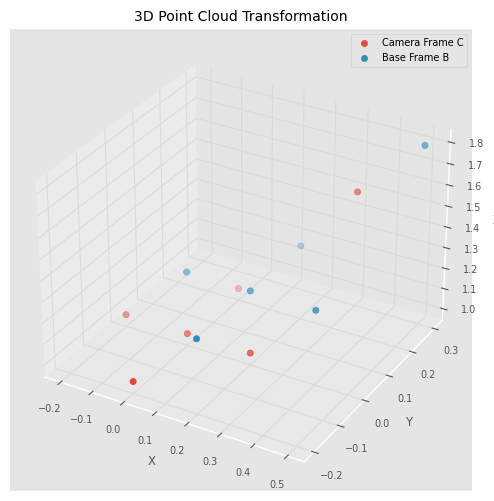

In [41]:
"""
Test the camera-to-base transformation 
with several known points and visualize them.
"""

# Example point cloud in camera frame
points_C = np.array([
        [0.0, 0.0, 1.0],   # directly in front
        [0.2, 0.0, 1.0],   # right
        [-0.2, 0.0, 1.0],  # left
        [0.0, 0.2, 1.0],   # up
        [0.0, -0.2, 1.0],  # down
        [0.3, 0.3, 1.5]
    ])

# Transform all points
points_B = np.array([cam_to_base(T_BC, p) for p in points_C])

# Print transformed points
print("=== Camera Frame Points ===")
print(points_C)

print("\n=== Base Frame Points ===")
print(points_B)

# Visualization
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Original camera-frame cloud
ax.scatter(points_C[:, 0], 
           points_C[:, 1], 
           points_C[:, 2], 
           label='Camera Frame C')

# Transformed base-frame cloud
ax.scatter(points_B[:, 0], 
           points_B[:, 1], 
           points_B[:, 2], label='Base Frame B')

# Labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("3D Point Cloud Transformation")
ax.legend()

plt.show()

### Mapping Full Pose T_CO → T_BO

In [42]:
def object_pose_in_base(T_BC, T_CO):
    return T_BC * T_CO # SE3 matrix multiplication

In [43]:
"""
Print and interpret the object pose
in the robot base frame.
"""

# Extract rotation and translation
R = T_BO.R
t = T_BO.t

print("\n=== Object Pose in Base Frame ===")

print("\nRotation Matrix R_BO:\n", R)

print("\nTranslation Vector t_BO:\n", t)

x, y, z = t

print("\n=== Geometric Interpretation ===")

# Front / behind
if x > 0:
    print(f"- Object is {x:.2f} m in front of the robot.")
else:
    print(f"- Object is {abs(x):.2f} m behind the robot.")

# Left / right
if y > 0:
    print(f"- Object is {y:.2f} m to the left of the robot.")
else:
    print(f"- Object is {abs(y):.2f} m to the right of the robot.")

# Height
if z > 0:
    print(f"- Object is {z:.2f} m above the robot base.")
else:
    print(f"- Object is {abs(z):.2f} m below the robot base.")


=== Object Pose in Base Frame ===

Rotation Matrix R_BO:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Translation Vector t_BO:
 [0.35 0.05 0.3 ]

=== Geometric Interpretation ===
- Object is 0.35 m in front of the robot.
- Object is 0.05 m to the left of the robot.
- Object is 0.30 m above the robot base.


Print the resulting R and t components of T_BO. Interpret them geometrically: where is the object in the base frame? Is it in front of, behind, or to the side of the robot?

Students should be able to read a 4×4 SE3 matrix and immediately locate the object in 3D space. This geometric intuition is critical for debugging real-world deployments.

In [44]:
def ik_solver(robot, T_target):
    """
    Solve inverse kinematics for a desired end-effector pose.

    Parameters
    ----------
    robot : roboticstoolbox robot model
        Robot instance (e.g., Panda, UR5, etc.)

    T_target : SE3
        Desired end-effector pose in base frame

    Returns
    -------
    q_solution : ndarray
        Joint configuration solving the IK problem
    """

    # Numerical IK solver
    solution = robot.ikine_LM(T_target)

    # Check if solver succeeded
    if not solution.success:
        raise ValueError("IK solver failed to find a solution.")

    q_solution = solution.q

    return q_solution

In [45]:
### Build T_target and Run IK
def build_target(T_BO, T_OT):
    T_BT = T_BO * T_OT
    return T_BT

robot = Panda()

# Use IK
T_target = build_target(T_BO, T_OT)
q_target = ik_solver(robot, T_target)
print("Joint angles:", q_target)

Joint angles: [ 1.11074165  0.85046311 -0.61598276 -2.48360565 -1.38417387  0.45772686
  1.88975545]


This is the first time in the course that the full chain — `AI pose → mapping → IK → joint angles` — runs end-to-end in student code.

### Full Pipeline with Simulated AI Data

Scale up: mock a scene with multiple objects and run the complete pipeline for each.

In [46]:
# Simulated AI output: 3 objects on the table

objects = [SE3(0.15, 0.05, 0.0), # Object 1
           SE3(0.20, -0.03, 0.0), # Object 2
           SE3(0.10, 0.08, 0.0)] # Object 3

for T_CO in objects:
    T_BO = T_BC * T_CO
    T_BT = T_BO * T_OT
    q = ik_solver(robot, T_BT)
    print(f"Grasp joint angles: {q}")

Grasp joint angles: [-1.98799455 -0.87354201  2.49167306 -2.48625061 -1.3738482   0.49273389
  1.8793628 ]
Grasp joint angles: [-2.41692486 -0.82292719  2.61486123 -2.37938685 -1.60116022  0.37763912
  1.97547426]
Grasp joint angles: [-0.11886929  0.68742984  0.10188262 -2.48747935  1.12679543  0.07152854
 -1.19037654]


This simulates the robot sequentially grasping all detected objects — a preview of the final course demo scenario.

### Effect of Calibration Errors

Deliberately corrupt `T_BC` with small errors to quantify their effect on grasp accuracy.

- **Translation Error**: Add 1–2 cm offset to the t component of `T_BC`. Observe how the grasp point shifts in a fixed direction — a classic sign of calibration drift.

- **Rotation Error**: Apply a small rotation (2–3°) to the R component. Observe how grasp error grows with object distance from the camera optical axis.

- **Key Takeaway**: Even small calibration errors cause systematic (not random) grasp failures — the robot always misses in the same direction. This is the diagnostic signature of a calibration problem.


### Connect to Real Hardware

Apply the full pipeline to a physical robot. Place 1–2 objects at known positions on
the table. Run mapping + IK and command the arm to approach each grasp pose. If physical grasp is not yet configured, visualize the trajectory in Swift simulator and confirm correctness visually.

## Extra Practice

### Sources of Error in the Grasp Pipeline

Errors compound through the chain. The cumulative effect can easily exceed the tolerance of a standard gripper. Design the gripper to compensate for the expected total error budget.

<img src="cpv-images/grasp_pipeline.png" width=800px height=400px />

### Impact of AI Pose Errors

If `T_CO` from the 6D pose network contains errors of a few mm or a few degrees, T_target will be offset by the same amount. This error is then fed directly into IK, which solves correctly — but for the wrongtarget position.

**Mitigation Strategies**:
- Use larger, more textured objects for better pose estimation
- Average pose estimates over multiple frames
- Design grippers with wide contact surfaces
- Use vacuum suction or chamfered guides for tolerance

The IK solver always "succeeds" even when the target is wrong. All quality control must happen upstream — at the camera and calibration stage.

### Impact of Hand-Eye Calibration Errors

- **Systematic Offset**: A wrong `T_BC` shifts everygrasp in the same direction by the same amount. If the robot consistently misses objects to the left by 3 cm, suspect a calibration error — not a pose estimation or IK issue.

- **When to Recalibrate**: Recalibrate hand-eye whenever: the camera mount is accidentally bumped, the camera bracket is reassembled, or you observe a new systematic grasp offset that wasn't present before.

- **Best Practice**: In production systems, build a periodic recalibration routine. Run it at the start of each work session or after any physical intervention on the robot. Takes less than 5 minutes with a proper calibration fixture.

### Mapping, IK, and Their Tight Coupling

**The Chain of Responsibility**

- Mapping produces `T_target`. IK converts `T_target` into joint angles `q_target`. The IK solver is blind to whether `T_target` is correct — it simply finds the best solution to reach the given pose.

- Consequence: Debugging a missed grasp requires tracing backward through the chain to find where the error was introduced.

**Debugging Order**

- Check calibration first: Is T_BC accurate? Use ground-truth markers.

- Check AI pose: Is T_CO reasonable? Project back to pixels.

- Check IK: Did IK converge? Check residual error.

### Extending to Mobile Robots

The same mapping concept applies to mobile robots, with one additional frame: the world/map frame W.

In [47]:
# Example 3D point detected by the camera
# Coordinates are expressed in the CAMERA frame

Xc = 0.25   # meters along camera X-axis
Yc = -0.10  # meters along camera Y-axis
Zc = 1.20   # meters along camera Z-axis (depth)

T_BC = SE3(0.30, 0.00, 0.50) * SE3.Rz(np.pi / 6)
T_WB = SE3(2.0, 1.0, 0.0) * SE3.Rz(np.pi / 4)

# T_WB from SLAM or odometry (pose of base in world/map)
# T_BC from hand-eye calibration (fixed)
p_C = np.array([Xc, Yc, Zc, 1.0]) # point in camera frame
p_B = T_BC.A @ p_C # camera → base
p_W = T_WB.A @ p_B # base → world/map

print("Point in Camera Frame:", p_C)
print("Point in Base Frame:", p_B)
print("Point in World Frame:", p_W)

Point in Camera Frame: [ 0.25 -0.1   1.2   1.  ]
Point in Base Frame: [0.56650635 0.03839746 1.7        1.        ]
Point in World Frame: [2.37342938 1.42773159 1.7        1.        ]


The path planner uses `p_W` to decide where to navigate. The structure is identical to the arm mapping — just one extra frame in the chain.

### Homography: A Simpler Alternative for Flat Scenes

**When to Use Homography**

- If objects lie on a known flat surface `(Z = Z₀)`, a homography matrix H directly maps pixel coordinates to 2D table coordinates — no 6D pose needed. Useful for pick-and-place on flat conveyor belts or tabletops.

**6D Pose vs. Homography**

- 6D Pose: full (x,y,z,roll,pitch,yaw) — flexible, general,
requires more data

- Homography: 2.5D only — simpler, but limited to flat objects
and fixed camera

RCV prioritizes 6D pose to develop general concepts applicable to all future scenarios.

## Discussion — Mapping & Hand- Eye Calibration

<img src="cpv-images/calibrator.png" width=600px height=400px />

Open forum for real-world scenarios and edge cases.

- What happens if the camera mount vibrates slightly during operation? How would you detect and compensate for this?

- If the table is slightly tilted (not perfectly horizontal), how does this affect the grasp pipeline and what correction would you apply?

- Changing lighting conditions affect the AI 6D pose output. At what stage in the pipeline does this error appear, and how would you mitigate it?